# NB2 — Regression with Featured Data Only
**Key differences from NB1:**
- Featured engineered columns only (no raw stats)
- StandardScaler normalization
- Sample weighting: 2023/24=0.5, 2024/25=0.75, 2025/26=1.0
- 85/15 walk-forward split (GW15-29 of 2025/26 as test)
- No ensemble — best PyCaret model vs AutoKeras, winner selected by MAE

---
## ⚠️ Two Sessions Required
- **Session 1:** PyCaret
- **Session 2:** AutoKeras (restart runtime)

Cells 1-5 (Setup through Normalization) must be re-run in Session 2.

## 1. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True, timeout_ms=120000)
import os
BASE = '/content/drive/MyDrive/fpl_thesis'
os.makedirs(f'{BASE}/data/processed/nb2_regression_featured', exist_ok=True)
os.makedirs(f'{BASE}/models/nb2_regression_featured', exist_ok=True)
print('Drive mounted and folders ready')

Mounted at /content/drive
Drive mounted and folders ready


## 2. Load Featured Dataset

In [2]:
import pandas as pd
import numpy as np

DATA_PATH = f'{BASE}/data/processed/featured_training_set.csv'
df = pd.read_csv(DATA_PATH)
df = df.sort_values(['element', 'season', 'GW']).reset_index(drop=True)
print(f'Loaded: {df.shape}')
print(df.head(3))

Loaded: (79277, 34)
              name     team position  element  season  GW  total_points  \
0  Folarin Balogun  Arsenal      FWD        1    2324   1             0   
1  Folarin Balogun  Arsenal      FWD        1    2324   2             0   
2  Folarin Balogun  Arsenal      FWD        1    2324   3             0   

   value  price_change  pts_per_million  ...  played_60_plus  blanked  \
0    4.5           0.0              0.0  ...               0        1   
1    4.5           0.0              0.0  ...               0        1   
2    4.5           0.0              0.0  ...               0        1   

   red_card_flag  opp_avg_goals_scored  opp_avg_goals_conceded  \
0              0                   NaN                     NaN   
1              0              0.060606                0.333333   
2              0              0.045009                0.166667   

   team_rolling_pts_3  team_rolling_goals_3  gi_rate  rolling_yellows_3  \
0                 NaN                   NaN   

## 3. Define Features and Target

In [3]:
# Metadata — not used in training
META_COLS = ['name', 'team', 'position', 'element', 'season', 'GW', 'total_points']

FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
print(f'Feature columns ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)

# Target: next GW points (shift -1 within each player-season)
df['target'] = df.groupby(['element', 'season'])['total_points'].shift(-1)
df = df.dropna(subset=['target']).reset_index(drop=True)
print(f'\nAfter target shift: {df.shape}')

# Filter out rows where player has no recent minutes (non-playing / rotation risk)
# This removes the constant 0-point rows that drag predictions down
# We keep all rows in the test set for honest evaluation
df_playing = df[df['rolling_mins_3'] > 0].copy()
print(f'After filtering non-players: {df_playing.shape}')
print(f'Removed {len(df) - len(df_playing)} rows ({(len(df)-len(df_playing))/len(df)*100:.1f}% of data)')

Feature columns (27):
['value', 'price_change', 'pts_per_million', 'position_enc', 'rolling_pts_3', 'rolling_pts_5', 'rolling_pts_std_3', 'rolling_pts_std_5', 'rolling_goals_3', 'rolling_assists_3', 'rolling_mins_3', 'rolling_gi_3', 'form_trend', 'pct_matches_played', 'games_played', 'was_home', 'team_match_result', 'played_60_plus', 'blanked', 'red_card_flag', 'opp_avg_goals_scored', 'opp_avg_goals_conceded', 'team_rolling_pts_3', 'team_rolling_goals_3', 'gi_rate', 'rolling_yellows_3', 'transfers_per_selected']

After target shift: (76834, 35)
After filtering non-players: (38297, 35)
Removed 38537 rows (50.2% of data)


## 4. Walk-Forward Split (85/15)
- **Train:** 2023/24 + 2024/25 + GW1-14 of 2025/26
- **Test:** GW15-29 of 2025/26

In [4]:
train = df[~((df['season'] == 2526) & (df['GW'] >= 15))].copy()
test  = df[  (df['season'] == 2526) & (df['GW'] >= 15)].copy()

print(f'Train: {len(train)} rows ({len(train)/len(df_playing)*100:.1f}%)')
print(f'Test:  {len(test)} rows ({len(test)/len(df_playing)*100:.1f}%)')

X_train = train[FEATURE_COLS]
y_train = train['target']
X_test  = test[FEATURE_COLS]
y_test  = test['target']

# Sample weights — recent seasons matter more
weight_map = {2324: 0.5, 2425: 0.75, 2526: 1.0}
sample_weights = train['season'].map(weight_map).values
print(f'\nSample weight counts:')
print(train['season'].value_counts().sort_index())

# Naive baseline
from sklearn.metrics import mean_absolute_error, r2_score
naive_mae = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
print(f'\nNaive baseline MAE: {naive_mae:.4f}')

Train: 65642 rows (171.4%)
Test:  11192 rows (29.2%)

Sample weight counts:
season
2324    28500
2425    26801
2526    10341
Name: count, dtype: int64

Naive baseline MAE: 1.5055


In [5]:
# Combined weights: season importance × playing time × target value
def get_combined_weight(row):
    season_w = {2324: 0.5, 2425: 0.75, 2526: 1.0}[row['season']]

    if row['rolling_mins_3'] < 30:
        return season_w * 0.3   # rarely plays — downweight
    elif row['target'] <= 1:
        return season_w * 0.5   # played but blanked
    elif row['target'] <= 5:
        return season_w * 1.0   # normal game
    elif row['target'] <= 9:
        return season_w * 2.0   # good game
    else:
        return season_w * 3.0   # haul

sample_weights = train.apply(get_combined_weight, axis=1).values

print('Combined weight distribution:')
import pandas as pd
w_series = pd.Series(sample_weights)
print(w_series.describe())
print(f'\nWeight sum: {sample_weights.sum():.0f}')

Combined weight distribution:
count    65642.000000
mean         0.365296
std          0.361644
min          0.150000
25%          0.150000
50%          0.225000
75%          0.375000
max          3.000000
dtype: float64

Weight sum: 23979


## 5. Imputation and Normalization

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pickle

# Impute NaNs from rolling features at season start
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Scale — fit on train only to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Save for dashboard use
with open(f'{BASE}/models/nb2_regression_featured/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(f'{BASE}/models/nb2_regression_featured/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled:  {X_test_scaled.shape}')
print('Scaler and imputer saved')

X_train_scaled: (65642, 27)
X_test_scaled:  (11192, 27)
Scaler and imputer saved


---
# SESSION 1 — PyCaret
Run fully, save outputs, then restart runtime for Session 2.

## 6. Install PyCaret

In [ ]:
!pip install scikit-learn==1.4.2 pycaret==3.3.2 -q
print('PyCaret installed')

PyCaret installed


## 7. PyCaret Benchmarking

In [ ]:
import pandas as pd
import numpy as np
from pycaret.regression import *
from sklearn.metrics import mean_absolute_error, r2_score

# Build scaled DataFrame for PyCaret
train_pc = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
train_pc['target'] = y_train.values

# Setup — disable internal preprocessing since we already scaled
s = setup(
    data               = train_pc,
    target             = 'target',
    session_id         = 42,
    normalize          = False,   # already done
    imputation_type    = None,    # already done
    data_split_shuffle = False,   # respect temporal order
    fold               = 5,
    verbose            = False,
)
print('PyCaret setup complete')

PyCaret setup complete


In [ ]:
# Compare all models sorted by MAE
best_models = compare_models(
    sort    = 'MAE',
    n_select= 3,
    exclude = ['ransac'],
    verbose = True,
)
print(f'\nTop 3 models: {[type(m).__name__ for m in best_models]}')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.9886,4.9806,2.2239,0.1866,0.5288,0.6310,0.3380
lightgbm,Light Gradient Boosting Machine,1.1080,4.3596,2.0817,0.2865,0.5370,0.7727,1.5440
gbr,Gradient Boosting Regressor,1.1167,4.3222,2.0730,0.2924,0.5373,0.7637,7.0920
br,Bayesian Ridge,1.1533,4.3485,2.0801,0.2869,0.5503,0.7731,0.0540
ridge,Ridge Regression,1.1538,4.3487,2.0801,0.2868,0.5505,0.7740,0.0400
lr,Linear Regression,1.1539,4.3492,2.0803,0.2868,0.5505,0.7738,1.5840
lar,Least Angle Regression,1.1540,4.3509,2.0806,0.2865,0.5506,0.7746,0.0380
xgboost,Extreme Gradient Boosting,1.1662,4.6903,2.1587,0.2331,0.5628,0.8279,2.1720
knn,K Neighbors Regressor,1.1858,5.1490,2.2634,0.1557,0.5955,0.8953,1.8380
rf,Random Forest Regressor,1.1887,4.5609,2.1290,0.2538,0.5741,0.8678,29.4940


Processing:   0%|          | 0/79 [00:00<?, ?it/s]


Top 3 models: ['HuberRegressor', 'LGBMRegressor', 'GradientBoostingRegressor']


## 8. Tune and Evaluate Best PyCaret Model

In [ ]:
best = best_models[0]
print(f'Best model: {type(best).__name__}')

# Tune
tuned = tune_model(best, optimize='MAE', n_iter=20, verbose=False)

# Evaluate on test set
test_pc = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)
preds_pc = predict_model(tuned, data=test_pc)
pc_pred_values = np.clip(preds_pc['prediction_label'].values, 0, None)

mae_pc = mean_absolute_error(y_test, pc_pred_values)
r2_pc  = r2_score(y_test, pc_pred_values)
print(f'\nPyCaret Best Model Test Results:')
print(f'  MAE: {mae_pc:.4f}')
print(f'  R²:  {r2_pc:.4f}')
print(f'  vs Naive: {((naive_mae - mae_pc)/naive_mae)*100:.1f}% improvement')

Best model: HuberRegressor



PyCaret Best Model Test Results:
  MAE: 0.8644
  R²:  0.2126
  vs Naive: 42.6% improvement


## 9. Confidence Analysis — PyCaret

PyCaret — MAE by prediction range:
              mean       std  count
pred_bin                           
0-2 pts   0.901766  1.881387   7200
2-4 pts   2.248729  2.547381   1364
4-6 pts        NaN       NaN      0
6+ pts         NaN       NaN      0


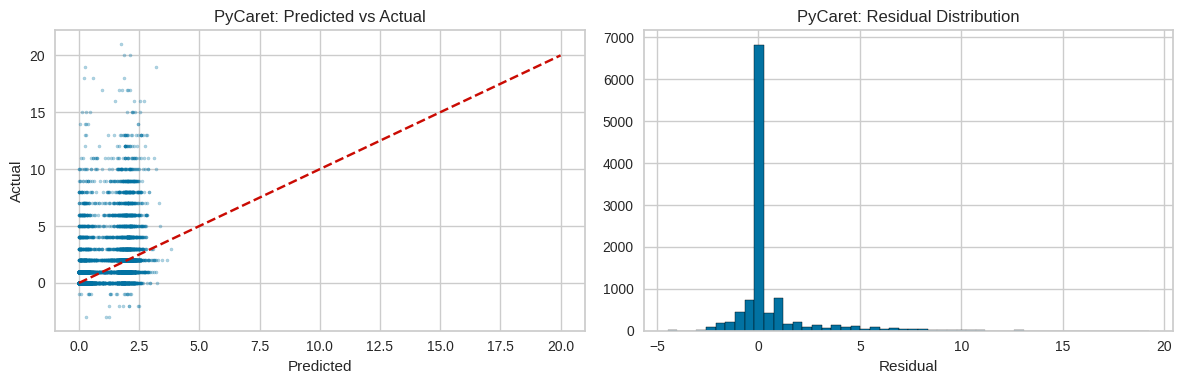

Confidence plot saved


In [ ]:
# Analyse prediction distribution and confidence
import matplotlib.pyplot as plt

residuals = y_test.values - pc_pred_values
abs_errors = np.abs(residuals)

# Confidence bins based on predicted value ranges
bins = [0, 2, 4, 6, np.inf]
labels = ['0-2 pts', '2-4 pts', '4-6 pts', '6+ pts']
pred_bins = pd.cut(pc_pred_values, bins=bins, labels=labels)

conf_df = pd.DataFrame({
    'predicted': pc_pred_values,
    'actual': y_test.values,
    'abs_error': abs_errors,
    'pred_bin': pred_bins
})

print('PyCaret — MAE by prediction range:')
print(conf_df.groupby('pred_bin')['abs_error'].agg(['mean','std','count']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pc_pred_values, y_test.values, alpha=0.3, s=5)
axes[0].plot([0, 20], [0, 20], 'r--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('PyCaret: Predicted vs Actual')
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual'); axes[1].set_title('PyCaret: Residual Distribution')
plt.tight_layout()
plt.savefig(f'{BASE}/data/processed/nb2_regression_featured/pycaret_confidence.png', dpi=150)
plt.show()
print('Confidence plot saved')

## 10. Save PyCaret Model and Predictions

In [ ]:
import pickle

save_model(tuned, f'{BASE}/models/nb2_regression_featured/pycaret_best_model')

# Save predictions
preds_df = test[['name', 'team', 'position', 'element', 'season', 'GW']].copy().reset_index(drop=True)
preds_df['y_true']       = y_test.values
preds_df['pycaret_pred'] = pc_pred_values
preds_df.to_csv(f'{BASE}/data/processed/nb2_regression_featured/preds_session1.csv', index=False)

# Save metrics for comparison
metrics = {'naive_mae': naive_mae, 'mae_pc': mae_pc, 'r2_pc': r2_pc,
           'model_name': type(best).__name__}
import json
with open(f'{BASE}/data/processed/nb2_regression_featured/metrics_session1.json', 'w') as f:
    json.dump(metrics, f)

print('PyCaret model and predictions saved')
print('→ Restart runtime and run Session 2 (AutoKeras)')

Transformation Pipeline and Model Successfully Saved
PyCaret model and predictions saved
→ Restart runtime and run Session 2 (AutoKeras)


---
# SESSION 2 — AutoKeras
⚠️ Restart runtime before this section.
Re-run cells 1–5 (Mount → Normalization) before continuing.

## 11. Install AutoKeras

In [8]:
!pip install autokeras==3.0.0 tensorflow==2.18.0 -q
print('AutoKeras installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 18.9 MB/s eta 0:00:00
AutoKeras installed


## 12. AutoKeras Neural Architecture Search

In [ ]:
import autokeras as ak
import tensorflow as tf
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

print(f'TensorFlow: {tf.__version__}')
print(f'AutoKeras:  {ak.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.18.0
AutoKeras:  3.0.0
GPU available: True


In [ ]:
ak_model = ak.StructuredDataRegressor(
    max_trials   = 10,
    overwrite    = True,
    directory    = f'{BASE}/models/nb2_regression_featured/ak_trials',
    project_name = 'nb2_autokeras',
    seed         = 42
)

ak_model.fit(
    X_train_scaled,
    y_train.values,
    epochs           = 35,
    validation_split = 0.1,
    verbose          = 1
)

Trial 10 Complete [00h 01m 28s]
val_loss: 3.347727060317993

Best val_loss So Far: 3.186885356903076
Total elapsed time: 00h 16m 57s
Epoch 1/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 4.4767 - mean_squared_error: 4.4767
Epoch 2/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3.9882 - mean_squared_error: 3.9882
Epoch 3/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 4.0916 - mean_squared_error: 4.0916
Epoch 4/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.9684 - mean_squared_error: 3.9684
Epoch 5/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3.8830 - mean_squared_error: 3.8830
Epoch 6/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.9805 - mean_squared_error: 3.9805
Epoch 7/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3.9733 - mean_squared_error: 3.9733
Epoch 8/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.9596 - mean_squared_error: 3.9596
Epoch 9/35
2052/2052 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.7985 - mean_squared

## 13. Evaluate AutoKeras

In [ ]:
ak_preds = np.clip(ak_model.predict(X_test_scaled).flatten(), 0, None)

mae_ak = mean_absolute_error(y_test, ak_preds)
r2_ak  = r2_score(y_test, ak_preds)
print(f'AutoKeras Test MAE: {mae_ak:.4f}')
print(f'AutoKeras Test R²:  {r2_ak:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
AutoKeras Test MAE: 1.0222
AutoKeras Test R²:  0.3168


## 14. Confidence Analysis — AutoKeras

AutoKeras — MAE by prediction range:
              mean       std  count
pred_bin                           
0-2 pts   0.665458  1.228818   8093
2-4 pts   2.189044  2.042993   2369
4-6 pts   3.195822  2.313216    264
6+ pts    4.266276  0.695914      5


/tmp/ipython-input-3261627685.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(conf_ak.groupby('pred_bin')['abs_error'].agg(['mean','std','count']))


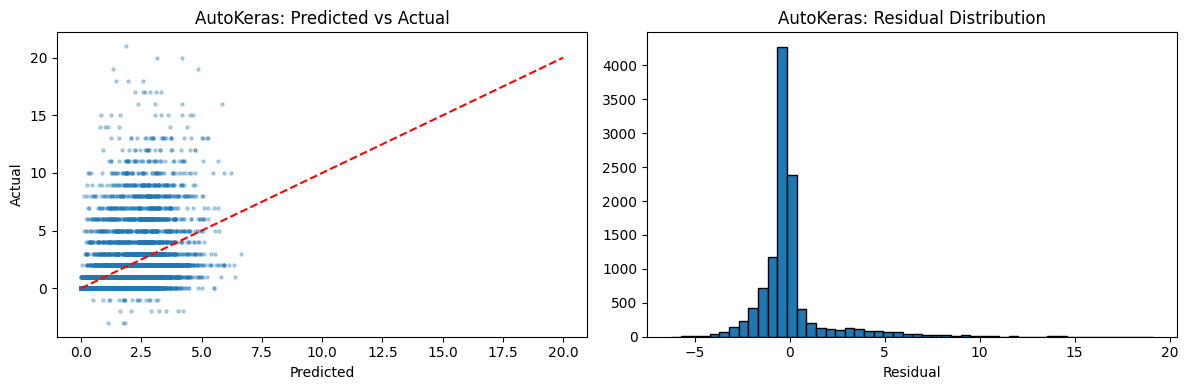

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

residuals_ak = y_test.values - ak_preds
abs_errors_ak = np.abs(residuals_ak)

bins = [0, 2, 4, 6, np.inf]
labels = ['0-2 pts', '2-4 pts', '4-6 pts', '6+ pts']
pred_bins_ak = pd.cut(ak_preds, bins=bins, labels=labels)

conf_ak = pd.DataFrame({
    'predicted': ak_preds,
    'actual': y_test.values,
    'abs_error': abs_errors_ak,
    'pred_bin': pred_bins_ak
})

print('AutoKeras — MAE by prediction range:')
print(conf_ak.groupby('pred_bin')['abs_error'].agg(['mean','std','count']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(ak_preds, y_test.values, alpha=0.3, s=5)
axes[0].plot([0, 20], [0, 20], 'r--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('AutoKeras: Predicted vs Actual')
axes[1].hist(residuals_ak, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual'); axes[1].set_title('AutoKeras: Residual Distribution')
plt.tight_layout()
plt.savefig(f'{BASE}/data/processed/nb2_regression_featured/autokeras_confidence.png', dpi=150)
plt.show()

## 15. Save AutoKeras Model

In [ ]:
best_ak = ak_model.export_model()
best_ak.save(f'{BASE}/models/nb2_regression_featured/autokeras_best_model.keras')
print('AutoKeras model saved')

# Add AutoKeras preds to session 1 predictions
preds_df = pd.read_csv(f'{BASE}/data/processed/nb2_regression_featured/preds_session1.csv')
preds_df['ak_pred'] = ak_preds
preds_df.to_csv(f'{BASE}/data/processed/nb2_regression_featured/all_preds.csv', index=False)
print('All predictions saved')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


AutoKeras model saved
All predictions saved


## 16. Model Comparison and Winner Selection

In [ ]:
import json

# Load session 1 metrics
with open(f'{BASE}/data/processed/nb2_regression_featured/metrics_session1.json') as f:
    m1 = json.load(f)

naive_mae  = m1['naive_mae']
mae_pc     = m1['mae_pc']
r2_pc      = m1['r2_pc']
model_name = m1['model_name']

print('='*50)
print('NB2 — FINAL MODEL COMPARISON')
print('='*50)
print(f'Naive Baseline MAE:      {naive_mae:.4f}')
print(f'PyCaret ({model_name}) MAE: {mae_pc:.4f}  R²: {r2_pc:.4f}')
print(f'AutoKeras MAE:           {mae_ak:.4f}  R²: {r2_ak:.4f}')
print()

if mae_pc <= mae_ak:
    winner = 'PyCaret'
    winner_mae = mae_pc
    winner_r2  = r2_pc
else:
    winner = 'AutoKeras'
    winner_mae = mae_ak
    winner_r2  = r2_ak

print(f'WINNER: {winner}')
print(f'  MAE: {winner_mae:.4f}')
print(f'  R²:  {winner_r2:.4f}')
print(f'  Improvement vs Naive: {((naive_mae-winner_mae)/naive_mae)*100:.1f}%')
print()
print('=== Comparison vs NB1 (all columns, no scaling) ===')
print(f'NB1 Huber MAE:     0.7969')
print(f'NB1 LightGBM MAE:  0.9301')
print(f'NB1 AutoKeras MAE: 0.9035')
print(f'NB2 Winner MAE:    {winner_mae:.4f}')

NB2 — FINAL MODEL COMPARISON
Naive Baseline MAE:      1.5055
PyCaret (HuberRegressor) MAE: 0.8644  R²: 0.2126
AutoKeras MAE:           1.0222  R²: 0.3168

WINNER: PyCaret
  MAE: 0.8644
  R²:  0.2126
  Improvement vs Naive: 42.6%

=== Comparison vs NB1 (all columns, no scaling) ===
NB1 Huber MAE:     0.7969
NB1 LightGBM MAE:  0.9301
NB1 AutoKeras MAE: 0.9035
NB2 Winner MAE:    0.8644


In [ ]:
!pip install numpy==1.26.4 -q


## 17. Generate Full Player Predictions (Winner Model)

In [ ]:
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import HuberRegressor

# Retrain Huber directly — same model PyCaret selected
winner = 'PyCaret (HuberRegressor)'
huber = HuberRegressor(epsilon=1.35, max_iter=200)
huber.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Save properly
with open(f'{BASE}/models/nb2_regression_featured/huber_model.pkl', 'wb') as f:
    pickle.dump(huber, f)
print('Huber model saved')

# Load full dataset for predictions
df_full = pd.read_csv(f'{BASE}/data/processed/featured_training_set.csv')
df_full = df_full.sort_values(['element', 'season', 'GW'])
latest  = df_full.groupby('element').last().reset_index()

META_COLS    = ['name', 'team', 'position', 'element', 'season', 'GW', 'total_points']
FEATURE_COLS = [c for c in df_full.columns if c not in META_COLS]
X_latest     = latest[FEATURE_COLS]

X_imp    = imputer.transform(X_latest)
X_scaled_latest = scaler.transform(X_imp)
X_df     = pd.DataFrame(X_scaled_latest, columns=FEATURE_COLS)

# Generate predictions
preds = np.clip(huber.predict(X_df), 0, None)

pos_map = {1:'DEF', 2:'FWD', 3:'GK', 4:'MID'}
out = latest[['name', 'team', 'position', 'element', 'value']].copy().reset_index(drop=True)
out['pos']           = latest['position_enc'].map(pos_map).values
out['predicted_pts'] = np.round(preds, 2)

out.to_csv(f'{BASE}/data/processed/nb2_regression_featured/predictions.csv', index=False)
print(f'Predictions saved: {len(out)} players')
print(f'Model: {winner}')
print(out.sort_values('predicted_pts', ascending=False).head(10)[
    ['name','team','pos','predicted_pts','value']])

Huber model saved
Predictions saved: 820 players
Model: PyCaret (HuberRegressor)
                              name       team  pos  predicted_pts  value
429                 Erling Haaland   Man City  FWD           8.10   14.7
380                  Mohamed Salah  Liverpool  MID           7.71   14.0
448         Bruno Borges Fernandes    Man Utd  MID           6.90   10.0
234                    Cole Palmer    Chelsea  MID           6.80   10.6
660                   Hugo Ekitiké  Liverpool  FWD           6.59    9.1
81                 Antoine Semenyo   Man City  MID           6.56    8.2
372                Virgil van Dijk  Liverpool  DEF           6.49    6.1
15                     Bukayo Saka    Arsenal  MID           6.49    9.8
4     Gabriel dos Santos Magalhães    Arsenal  DEF           6.33    7.1
248  João Pedro Junqueira de Jesus    Chelsea  FWD           6.22    7.6


In [ ]:
haaland = test[test['name'].str.contains('Haaland', case=False)][
    ['name', 'GW', 'total_points', 'value', 'rolling_pts_3']
].copy()
haaland_scaled = scaler.transform(imputer.transform(test[test['name'].str.contains('Haaland', case=False)][FEATURE_COLS]))
haaland['predicted'] = np.clip(huber.predict(haaland_scaled), 0, None)
print(haaland[['GW', 'total_points', 'predicted', 'rolling_pts_3']])

       GW  total_points  predicted  rolling_pts_3
43887  15             2   8.992886       6.000000
43888  16            13   8.901280       6.000000
43889  17            16   9.386172       9.666667
43890  18             2   9.539702      10.333333
43891  19             2   9.577258      10.333333
43892  20             2   8.988726       6.666667
43893  21             6   8.727034       2.000000
43894  22             2   8.641377       3.333333
43895  23             1   6.658821       3.333333
43896  24             5   8.013108       3.000000
43897  25            11   8.276681       2.666667
43898  26             5   7.442544       5.666667
43899  27             6   8.955533       7.000000
43900  28             0   7.557740       7.333333


In [ ]:
import pandas as pd
df = pd.read_csv(f'{BASE}/data/processed/nb2_regression_featured/predictions.csv')
print(df.columns.tolist())
print(df.head(3))

['name', 'team', 'position', 'element', 'value', 'pos', 'predicted_pts']
                         name     team position  element  value pos  \
0           David Raya Martín  Arsenal       GK        1    6.0  GK   
1  Kepa Arrizabalaga Revuelta  Arsenal       GK        2    4.1  GK   
2                   Karl Hein  Arsenal       GK        3    4.0  GK   

   predicted_pts  
0           4.68  
1           0.00  
2           0.00  


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/fpl_thesis/models/nb1_regression_all/predictions.csv')
print(df.columns.tolist())
print(df.shape)
print(df.head(3))

['name', 'team', 'position', 'element', 'GW', 'value', 'predicted_pts_mid', 'actual_pts']
(11192, 8)
                name     team  position  element  GW  value  \
0  David Raya Martín  Arsenal         2        1  15    5.9   
1  David Raya Martín  Arsenal         2        1  16    6.0   
2  David Raya Martín  Arsenal         2        1  17    6.0   

   predicted_pts_mid  actual_pts  
0               2.43         2.0  
1               2.35         7.0  
2               2.26         2.0  


In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

BASE = '/content/drive/MyDrive/fpl_thesis'

# Load featured dataset
df = pd.read_csv(f'{BASE}/data/processed/featured_training_set.csv')
df = df.sort_values(['element', 'season', 'GW']).reset_index(drop=True)

# Recreate target
df['target'] = df.groupby(['element', 'season'])['total_points'].shift(-1)
df = df.dropna(subset=['target']).reset_index(drop=True)

# Get test set (GW15-29 of 2025/26)
META_COLS = ['name', 'team', 'position', 'element', 'season', 'GW', 'total_points', 'target']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
test = df[(df['season'] == 2526) & (df['GW'] >= 15)].copy()

# Load saved scaler and imputer
with open(f'{BASE}/models/nb2_regression_featured/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(f'{BASE}/models/nb2_regression_featured/imputer.pkl', 'rb') as f:
    imputer = pickle.load(f)

X_test = test[FEATURE_COLS]
X_imp = imputer.transform(X_test)
X_scaled = scaler.transform(X_imp)

# Load Huber model
with open(f'{BASE}/models/nb2_regression_featured/huber_model.pkl', 'rb') as f:
    huber = pickle.load(f)

preds = np.clip(huber.predict(X_scaled), 0, None)

# Save per-GW predictions
out = test[['name', 'team', 'position', 'element', 'GW', 'value']].copy().reset_index(drop=True)
out['predicted_pts_mid'] = np.round(preds, 2)
out['actual_pts'] = test['total_points'].values

out.to_csv(f'{BASE}/models/nb2_regression_featured/predictions_pergw.csv', index=False)
print(f'Saved: {out.shape}')
print(out.head(3))

Saved: (11192, 8)
                name     team position  element  GW  value  predicted_pts_mid  \
0  David Raya Martín  Arsenal       GK        1  15    5.9                4.5   
1  David Raya Martín  Arsenal       GK        1  16    6.0                4.5   
2  David Raya Martín  Arsenal       GK        1  17    6.0                4.5   

   actual_pts  
0           2  
1           2  
2           7  


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HuberRegressor from version 1.4.2 when using version 1.6.1. This might lead to breaking code or i

In [9]:
import tensorflow as tf
import autokeras as ak
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

BASE = '/content/drive/MyDrive/fpl_thesis'

# Load nb2 test data
nb2 = pd.read_csv(f'{BASE}/models/nb2_regression_featured/predictions_pergw.csv')

# Load AutoKeras model
ak_model = tf.keras.models.load_model(
    f'{BASE}/models/nb2_regression_featured/autokeras_best_model.keras',
    custom_objects=ak.CUSTOM_OBJECTS
)

# We need X_test_scaled — rerun cells 1-5 of nb2 first
# Then:
ak_preds = np.clip(ak_model.predict(X_test_scaled).flatten(), 0, None)

nb2['ak_pred'] = ak_preds

# MAE@K comparison
def mae_at_k(y_true, y_pred, actual_pts, k=15):
    errors = []
    gws = actual_pts.index if hasattr(actual_pts, 'index') else range(len(actual_pts))
    return errors

# Build comparison DataFrame
compare = nb2.copy()
compare['huber_pred'] = compare['predicted_pts_mid']
compare['ak_pred'] = ak_preds

def mae_at_k(df, pred_col, k=15):
    errors = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_k = gw_df.nlargest(k, 'actual_pts')
        errors.append(mean_absolute_error(top_k['actual_pts'], top_k[pred_col]))
    return np.mean(errors)

for k in [10, 15, 20, 30]:
    h = mae_at_k(compare, 'huber_pred', k)
    a = mae_at_k(compare, 'ak_pred', k)
    winner = 'Huber' if h < a else 'AutoKeras'
    print(f'MAE@{k}: Huber={h:.4f}  AutoKeras={a:.4f}  → {winner}')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
MAE@10: Huber=8.2369  AutoKeras=8.8613  → Huber
MAE@15: Huber=7.3370  AutoKeras=7.9018  → Huber
MAE@20: Huber=6.6674  AutoKeras=7.2023  → Huber
MAE@30: Huber=5.7268  AutoKeras=6.2041  → Huber


K       Huber MAE@K     AK MAE@K    Huber P@K       AK P@K
----------------------------------------------------------
10           8.2369       8.8613        0.143        0.071
15           7.3370       7.9018        0.181        0.110
20           6.6674       7.2023        0.196        0.139
30           5.7268       6.2041        0.260        0.226


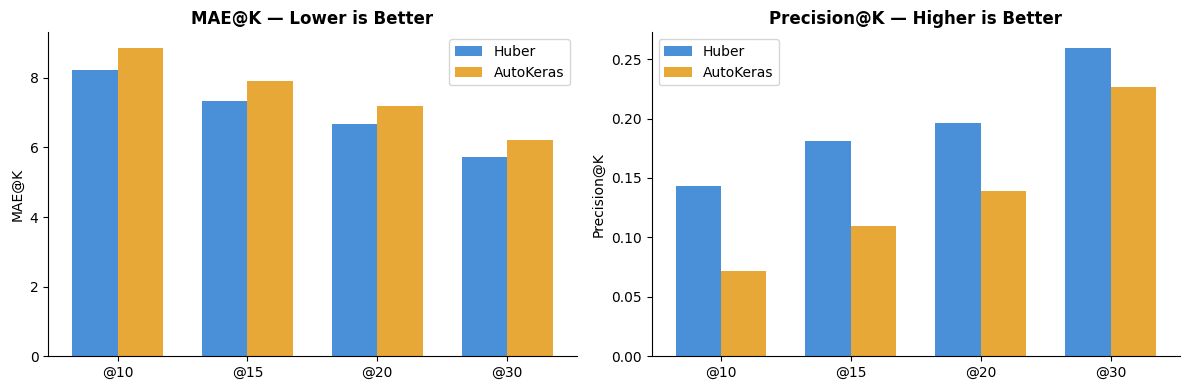

Saved.


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

def precision_at_k(df, pred_col, k=15):
    scores = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_pred   = set(gw_df.nlargest(k, pred_col)['element'])
        top_actual = set(gw_df.nlargest(k, 'actual_pts')['element'])
        scores.append(len(top_pred & top_actual) / k)
    return np.mean(scores)

ks = [10, 15, 20, 30]
huber_maek  = [mae_at_k(compare, 'huber_pred', k) for k in ks]
ak_maek     = [mae_at_k(compare, 'ak_pred', k)    for k in ks]
huber_preck = [precision_at_k(compare, 'huber_pred', k) for k in ks]
ak_preck    = [precision_at_k(compare, 'ak_pred', k)    for k in ks]

print(f'{"K":<6} {"Huber MAE@K":>12} {"AK MAE@K":>12} {"Huber P@K":>12} {"AK P@K":>12}')
print('-' * 58)
for k, hm, am, hp, ap in zip(ks, huber_maek, ak_maek, huber_preck, ak_preck):
    print(f'{k:<6} {hm:>12.4f} {am:>12.4f} {hp:>12.3f} {ap:>12.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(ks))
w = 0.35

axes[0].bar(x - w/2, huber_maek, w, label='Huber', color='#4a90d9', edgecolor='none')
axes[0].bar(x + w/2, ak_maek,    w, label='AutoKeras', color='#e8a838', edgecolor='none')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'@{k}' for k in ks])
axes[0].set_ylabel('MAE@K')
axes[0].set_title('MAE@K — Lower is Better', fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(x - w/2, huber_preck, w, label='Huber', color='#4a90d9', edgecolor='none')
axes[1].bar(x + w/2, ak_preck,    w, label='AutoKeras', color='#e8a838', edgecolor='none')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'@{k}' for k in ks])
axes[1].set_ylabel('Precision@K')
axes[1].set_title('Precision@K — Higher is Better', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb2_huber_vs_autokeras.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')